# Week 10: Natural Language Processing
## COMP 9130 — Applied Artificial Intelligence
## **Student Activity Notebook**

---

### 📋 Session Overview

**Business Scenario:** TrustShield AI is building an automated content moderation platform. Before deploying toxicity detection, your team needs to master NLP fundamentals — starting with sentiment analysis as a proof-of-concept.

**Dataset:** IMDB Movie Reviews (~5K subset) via Hugging Face `datasets` library

**Model:** DistilBERT (distilbert-base-uncased) — 66M parameters, 40% smaller than BERT-base

**Framework:** PyTorch + Hugging Face Transformers (first in-class use of this stack)

**⏰ TIMING GUIDE:**
| Time | Activity | Points |
|------|----------|--------|
| 0:00–0:20 | Quiz 9 (Week 10: NLP & Transformers prep) | 5 pts |
| 0:20–0:25 | Setup & Installs | — |
| 0:25–0:55 | Task 1: HF Ecosystem & Tokenization (instructor-led) | 5 pts |
| 0:55–1:10 | Instructor check — Task 1 | — |
| 1:10–1:20 | Break | — |
| 1:20–1:55 | Task 2: Embeddings & Attention Visualization | 5 pts |
| 1:55–2:10 | Instructor check — Task 2 | — |
| 2:10–2:45 | Task 3: Fine-tune DistilBERT (PyTorch loop) | 5 pts |
| 2:45–2:55 | Instructor check — Task 3 | — |
| 2:55–3:00 | Wrap-up & Mini Project 9 Introduction | — |

**🎯 KEY LEARNING GOALS:**
1. Navigate the Hugging Face ecosystem (tokenizers, models, datasets, pipelines)
2. Understand subword tokenization and how transformers represent text
3. Visualize and interpret transformer embeddings and attention patterns
4. Fine-tune a pre-trained transformer with a manual PyTorch training loop
5. Evaluate NLP models and analyze where they fail

1. Forgetting to move tensors to GPU (`.to(device)` on model AND data)
2. Not understanding the difference between tokenizer output keys (`input_ids`, `attention_mask`)
3. Confusing model output: `.logits` vs `.last_hidden_state` vs pipeline output
4. OOM errors — batch size too large or sequences too long
5. Forgetting `model.eval()` and `torch.no_grad()` during inference
6. First time with PyTorch in class — some may struggle with `.backward()`, optimizer step pattern

**📦 KEY DEPENDENCIES:** transformers, datasets, torch, scikit-learn, matplotlib, seaborn

---

## 🔧 Environment Setup

In [ ]:
# ============================================================
# CELL 1: Install dependencies
# ============================================================

!pip install -q transformers==4.40.0 datasets==2.19.0 accelerate==0.30.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.4/302.4 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


In [ ]:
!pip install --upgrade transformers fsspec sentence-transformers gcsfs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.4/512.4 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.9/612.9 kB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 12.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.3.1
    Uninstalling fsspec-2024.3.1:
      Successfully uninstalled fsspec-2024.3.1
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    

In [ ]:
!pip install fsspec==2024.3.1 gcsfs==2024.3.1 transformers>=4.41.0 sentence-transformers

In [ ]:
import transformers
import fsspec
print(f"Transformers version: {transformers.__version__}")
print(f"Fsspec version: {fsspec.__version__}")

Transformers version: 5.3.0
Fsspec version: 2024.3.1


In [ ]:
# ============================================================
# CELL 2: Imports and device setup
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report
)
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Hugging Face imports
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    pipeline
)
from datasets import load_dataset

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("\n✅ All imports successful!")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB

✅ All imports successful!


---

## 📥 Data Loading

- It provides standardized access to 70K+ datasets
- Datasets are downloaded and cached locally
- Built-in train/test splits — no manual splitting needed
- Arrow format = memory-efficient for large datasets

In [ ]:
# ============================================================
# CELL 3: Load IMDB dataset and create subset
# ============================================================

# Load full IMDB
full_dataset = load_dataset('imdb')
print(f"Full dataset: {full_dataset}")
print(f"\nTrain size: {len(full_dataset['train'])}")
print(f"Test size: {len(full_dataset['test'])}")
print(f"\nLabel mapping: 0 = negative, 1 = positive")

# Create manageable subsets (stratified)
train_dataset = full_dataset['train'].shuffle(seed=42).select(range(4000))
val_dataset = full_dataset['test'].shuffle(seed=42).select(range(1000))
test_dataset = full_dataset['test'].shuffle(seed=42).select(range(1000, 2000))

print(f"\n📊 Working subsets:")
print(f"  Train: {len(train_dataset)} samples")
print(f"  Val:   {len(val_dataset)} samples")
print(f"  Test:  {len(test_dataset)} samples")

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Full dataset: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train size: 25000
Test size: 25000

Label mapping: 0 = negative, 1 = positive

📊 Working subsets:
  Train: 4000 samples
  Val:   1000 samples
  Test:  1000 samples


In [ ]:
# ============================================================
# CELL 4: Explore the data
# ============================================================
# Look at a few examples
print("=" * 60)
print("SAMPLE REVIEWS")
print("=" * 60)

for i in range(3):
    review = train_dataset[i]
    label = "POSITIVE" if review['label'] == 1 else "NEGATIVE"
    text_preview = review['text'][:200] + "..." if len(review['text']) > 200 else review['text']
    print(f"\n[{label}] {text_preview}")
    print(f"  Length: {len(review['text'])} chars, {len(review['text'].split())} words")

# Class distribution
labels = train_dataset['label']
pos_count = sum(labels)
neg_count = len(labels) - pos_count
print(f"\n📊 Class distribution (train):")
print(f"  Positive: {pos_count} ({pos_count/len(labels)*100:.1f}%)")
print(f"  Negative: {neg_count} ({neg_count/len(labels)*100:.1f}%)")

# Review length distribution
word_counts = [len(text.split()) for text in train_dataset['text']]
print(f"\n📏 Review length (words):")
print(f"  Mean: {np.mean(word_counts):.0f}")
print(f"  Median: {np.median(word_counts):.0f}")
print(f"  Min: {np.min(word_counts)}, Max: {np.max(word_counts)}")

SAMPLE REVIEWS

[POSITIVE] There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F...
  Length: 758 chars, 125 words

[POSITIVE] This movie is a great. The plot is very true to the book which is a classic written by Mark Twain. The movie starts of with a scene where Hank sings a song with a bunch of kids called "when you stub y...
  Length: 675 chars, 131 words

[NEGATIVE] George P. Cosmatos' "Rambo: First Blood Part II" is pure wish-fulfillment. The United States clearly didn't win the war in Vietnam. They caused damage to this country beyond the imaginable and this mo...
  Length: 1038 chars, 177 words

📊 Class distribution (train):
  Positive: 1985 (49.6%)
  Negative: 2015 (50.4%)

📏 Review length (words):
  Mean: 230
  Median: 173
  Min: 12, Max: 1601


---

## 🎯 Task 1: Hugging Face Ecosystem & Tokenization (Instructor-Led)

**Time: ~30 min | Points: 5**

**Goal:** Get comfortable with Hugging Face tools — tokenizers, pipelines, and how transformers see text.

- Type this code live, explaining each step
- Pause after tokenizer output to let students inspect the numbers
- Draw the [CLS] token → hidden states → classification head pipeline on the board
- The `pipeline` demo is the "wow moment" — show it working before explaining HOW it works
- Max 15 min of coding, rest is discussion

In [ ]:
# ============================================================
# CELL 5: Load tokenizer and explore subword tokenization
# ============================================================

MODEL_NAME = 'distilbert-base-uncased'

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Explore vocabulary
print(f"Model: {MODEL_NAME}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print(f"Max sequence length: {tokenizer.model_max_length}")
print(f"Special tokens: {tokenizer.special_tokens_map}")

# Show subword tokenization on different examples
examples = [
    "This movie is great!",
    "The cinematography was breathtakingly beautiful.",
    "I absolutely hated this unwatchable catastrophe.",
    "The acting performances were extraordinary."
]

print("\n" + "=" * 60)
print("SUBWORD TOKENIZATION EXAMPLES")
print("=" * 60)

for text in examples:
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.encode(text)
    print(f"\nText:   {text}")
    print(f"Tokens: {tokens}")
    print(f"IDs:    {ids}")
    print(f"Count:  {len(tokens)} tokens from {len(text.split())} words")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model: distilbert-base-uncased
Vocabulary size: 30,522
Max sequence length: 512
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}

SUBWORD TOKENIZATION EXAMPLES

Text:   This movie is great!
Tokens: ['this', 'movie', 'is', 'great', '!']
IDs:    [101, 2023, 3185, 2003, 2307, 999, 102]
Count:  5 tokens from 4 words

Text:   The cinematography was breathtakingly beautiful.
Tokens: ['the', 'cinematography', 'was', 'breath', '##taking', '##ly', 'beautiful', '.']
IDs:    [101, 1996, 16434, 2001, 3052, 17904, 2135, 3376, 1012, 102]
Count:  8 tokens from 5 words

Text:   I absolutely hated this unwatchable catastrophe.
Tokens: ['i', 'absolutely', 'hated', 'this', 'un', '##watch', '##able', 'catastrophe', '.']
IDs:    [101, 1045, 7078, 6283, 2023, 4895, 18866, 3085, 25539, 1012, 102]
Count:  9 tokens from 6 words

Text:   The acting performances were extraordinary.
Tokens: ['the', 'acting', 'performances', 'were', 'e

In [ ]:
# ============================================================
# CELL 6: Tokenizer in detail — padding, truncation, attention mask
# ============================================================

# Tokenize two reviews of different lengths
short_text = "Great movie, loved it!"
long_text = train_dataset[0]['text']  # A full review

# Tokenize with padding and truncation
encoded = tokenizer(
    [short_text, long_text],
    padding=True,           # Pad shorter sequence to match longer
    truncation=True,        # Truncate to max_length
    max_length=256,         # We'll use 256 for efficiency
    return_tensors='pt'     # Return PyTorch tensors
)

print("Tokenizer output keys:", list(encoded.keys()))
print(f"\nShape of input_ids: {encoded['input_ids'].shape}")
print(f"Shape of attention_mask: {encoded['attention_mask'].shape}")

# Show the padding effect
print(f"\n--- Short text ---")
print(f"Text: {short_text}")
print(f"IDs (first 15):  {encoded['input_ids'][0][:15].tolist()}")
print(f"Mask (first 15): {encoded['attention_mask'][0][:15].tolist()}")
real_tokens_short = encoded['attention_mask'][0].sum().item()
print(f"Real tokens: {real_tokens_short}, Padding: {256 - real_tokens_short}")

print(f"\n--- Long text ---")
print(f"Text: {long_text[:80]}...")
print(f"IDs (first 15):  {encoded['input_ids'][1][:15].tolist()}")
print(f"Mask (first 15): {encoded['attention_mask'][1][:15].tolist()}")
real_tokens_long = encoded['attention_mask'][1].sum().item()
print(f"Real tokens: {real_tokens_long}, Padding: {256 - real_tokens_long}")

# Decode back to text to verify
print(f"\n🔄 Decoded short: {tokenizer.decode(encoded['input_ids'][0], skip_special_tokens=True)[:80]}")

Tokenizer output keys: ['input_ids', 'token_type_ids', 'attention_mask']

Shape of input_ids: torch.Size([2, 179])
Shape of attention_mask: torch.Size([2, 179])

--- Short text ---
Text: Great movie, loved it!
IDs (first 15):  [101, 2307, 3185, 1010, 3866, 2009, 999, 102, 0, 0, 0, 0, 0, 0, 0]
Mask (first 15): [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
Real tokens: 8, Padding: 248

--- Long text ---
Text: There is no relation at all between Fortier and Profiler but the fact that both ...
IDs (first 15):  [101, 2045, 2003, 2053, 7189, 2012, 2035, 2090, 3481, 3771, 1998, 6337, 2099, 2021, 1996]
Mask (first 15): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Real tokens: 179, Padding: 77

🔄 Decoded short: great movie, loved it!


In [ ]:
# ============================================================
# CELL 7: Pipeline API — zero-shot sentiment analysis
# ============================================================

# Create sentiment analysis pipeline
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=0 if torch.cuda.is_available() else -1
)

# Test on sample reviews
test_texts = [
    "This movie was absolutely fantastic! Best I've seen all year.",
    "Terrible waste of time. The plot made no sense whatsoever.",
    "It was okay. Nothing special but not terrible either.",
    "The special effects were amazing but the story was weak.",
    "I fell asleep halfway through. So boring."
]

print("=" * 60)
print("PIPELINE SENTIMENT ANALYSIS")
print("=" * 60)

results = sentiment_pipeline(test_texts)
for text, result in zip(test_texts, results):
    emoji = "😊" if result['label'] == 'POSITIVE' else "😞"
    print(f"\n{emoji} [{result['label']}] (conf: {result['score']:.3f})")
    print(f"   \"{text[:70]}...\"" if len(text) > 70 else f"   \"{text}\"")

# Clean up pipeline to free GPU memory
del sentiment_pipeline
torch.cuda.empty_cache() if torch.cuda.is_available() else None

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

PIPELINE SENTIMENT ANALYSIS

😊 [POSITIVE] (conf: 1.000)
   "This movie was absolutely fantastic! Best I've seen all year."

😞 [NEGATIVE] (conf: 1.000)
   "Terrible waste of time. The plot made no sense whatsoever."

😊 [POSITIVE] (conf: 0.985)
   "It was okay. Nothing special but not terrible either."

😞 [NEGATIVE] (conf: 0.999)
   "The special effects were amazing but the story was weak."

😞 [NEGATIVE] (conf: 1.000)
   "I fell asleep halfway through. So boring."


### 📝 Task 1 Analysis Questions

**Q1:** Look at your tokenization examples. How does DistilBERT handle words it hasn't seen before? Find a word from the examples above that was split into subwords and explain why this approach is better than using a fixed vocabulary that rejects unknown words.

> Word: breathtakingly

> Split into: ['breath', '##taking', '##ly']

> Word: unwatchable

> Split into: ['un', '##watch', '##able']

**Q2:** The pipeline gave a confidence score for the mixed-sentiment review ("special effects were amazing but the story was weak"). What was the label and confidence? Why might a content moderation system struggle with mixed-sentiment text like this?

---

- Explain what `input_ids` and `attention_mask` represent
- Identify where padding tokens appear in the output
- Run the pipeline and interpret results

**Checkpoint:** Ask each pair to show their pipeline output on the mixed-sentiment example.

> **input_ids:** These are the unique numerical integers mapped to each subword token in the DistilBERT vocabulary.

> **attention_mask:** This is a binary tensor (1 for real tokens, 0 for padding). It tells the model to ignore the [PAD] tokens so they don't influence the mathematical representation of the sentence.

> **Special Tokens:**

> [CLS] (ID 101): Added to the start; represents the aggregate sequence representation for classification.

> [SEP] (ID 102): Added to the end; marks the boundary of the text.

---

## 🎯 Task 2: Embeddings & Attention Visualization (Independent)

**Time: ~35 min | Points: 5**

**Goal:** Understand how DistilBERT represents text internally — embeddings capture meaning, attention shows what the model "looks at."

- `AutoModel` gives raw hidden states (768-dim vectors per token)
- `AutoModelForSequenceClassification` adds a classification head on top
- We use `AutoModel` here to peek inside, then the classification version in Task 3
- The [CLS] token embedding summarizes the whole sequence




In [ ]:
# ============================================================
# CELL 8: Load base model and extract embeddings
# ============================================================

# Load base DistilBERT (no classification head)
base_model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True)
base_model.to(device)
base_model.eval()  # Important: set to evaluation mode

print(f"Model: {MODEL_NAME}")
print(f"Parameters: {sum(p.numel() for p in base_model.parameters()):,}")
print(f"Hidden size: {base_model.config.hidden_size}")
print(f"Attention heads: {base_model.config.num_attention_heads}")
print(f"Layers: {base_model.config.num_hidden_layers}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: distilbert-base-uncased
Parameters: 66,362,880
Hidden size: 768
Attention heads: 12
Layers: 6


In [ ]:
# ============================================================
# CELL 9: Generate embeddings for a batch of reviews
# ============================================================

def get_cls_embeddings(texts, tokenizer, model, device, max_length=256):
    """Extract [CLS] token embeddings from DistilBERT.

    The [CLS] token (position 0) is trained to capture the
    meaning of the entire input sequence.
    """
    # Tokenize
    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    ).to(device)

    # Forward pass (no gradient computation needed)
    with torch.no_grad():
        outputs = model(**encoded)

    # Extract [CLS] embedding (first token, position 0)
    cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

# Get embeddings for a sample of reviews
n_samples = 200
sample_texts = train_dataset['text'][:n_samples]
sample_labels = train_dataset['label'][:n_samples]

# Process in batches to avoid OOM
batch_size = 32
all_embeddings = []

for i in range(0, n_samples, batch_size):
    batch_texts = sample_texts[i:i+batch_size]
    batch_emb = get_cls_embeddings(batch_texts, tokenizer, base_model, device)
    all_embeddings.append(batch_emb)
    print(f"  Processed {min(i+batch_size, n_samples)}/{n_samples} reviews")

embeddings = np.vstack(all_embeddings)
print(f"\nEmbedding matrix shape: {embeddings.shape}")
print(f"Each review → {embeddings.shape[1]}-dimensional vector")

  Processed 32/200 reviews
  Processed 64/200 reviews
  Processed 96/200 reviews
  Processed 128/200 reviews
  Processed 160/200 reviews
  Processed 192/200 reviews
  Processed 200/200 reviews

Embedding matrix shape: (200, 768)
Each review → 768-dimensional vector


Running t-SNE (this takes ~30 seconds)...


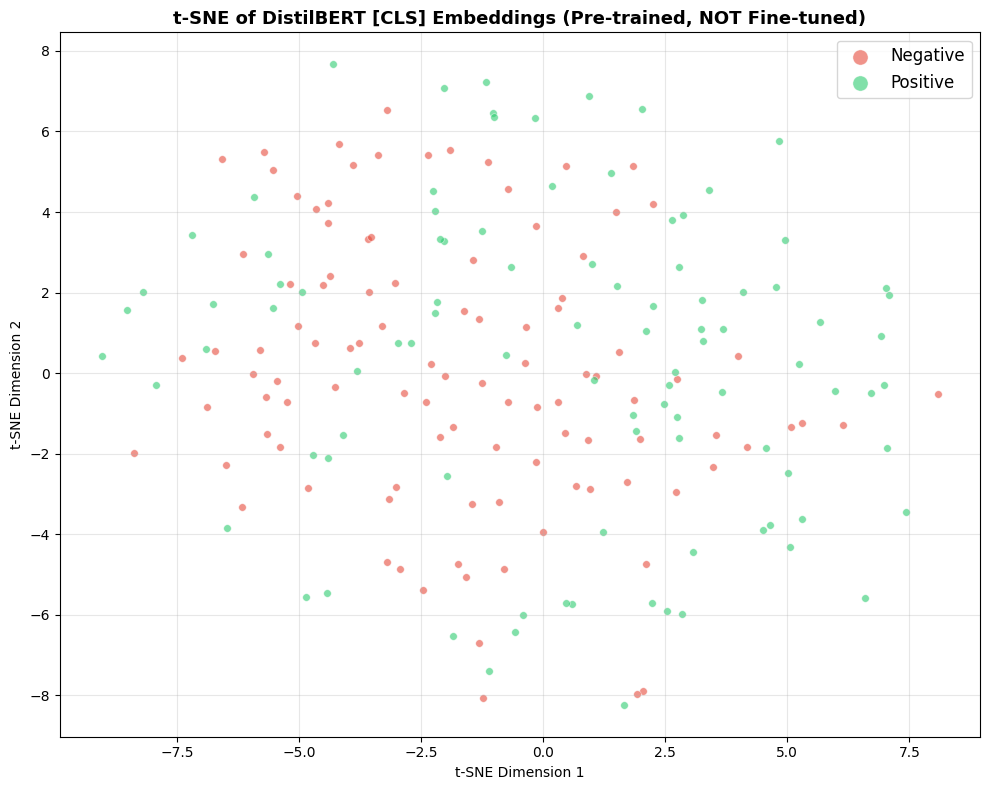


💡 Note: Some clustering is visible even WITHOUT fine-tuning.
   Pre-trained DistilBERT already 'understands' some sentiment.
   Fine-tuning in Task 3 will sharpen these clusters.


In [ ]:
# ============================================================
# CELL 10: t-SNE visualization of embeddings
# ============================================================

# Reduce to 2D with t-SNE
print("Running t-SNE (this takes ~30 seconds)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

colors = ['#e74c3c', '#2ecc71']  # Red=negative, Green=positive
label_names = ['Negative', 'Positive']

for label_idx in [0, 1]:
    mask = np.array(sample_labels) == label_idx
    ax.scatter(
        embeddings_2d[mask, 0], embeddings_2d[mask, 1],
        c=colors[label_idx], label=label_names[label_idx],
        alpha=0.6, s=30, edgecolors='white', linewidth=0.5
    )

ax.set_title('t-SNE of DistilBERT [CLS] Embeddings (Pre-trained, NOT Fine-tuned)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(fontsize=12, markerscale=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Note: Some clustering is visible even WITHOUT fine-tuning.")
print("   Pre-trained DistilBERT already 'understands' some sentiment.")
print("   Fine-tuning in Task 3 will sharpen these clusters.")

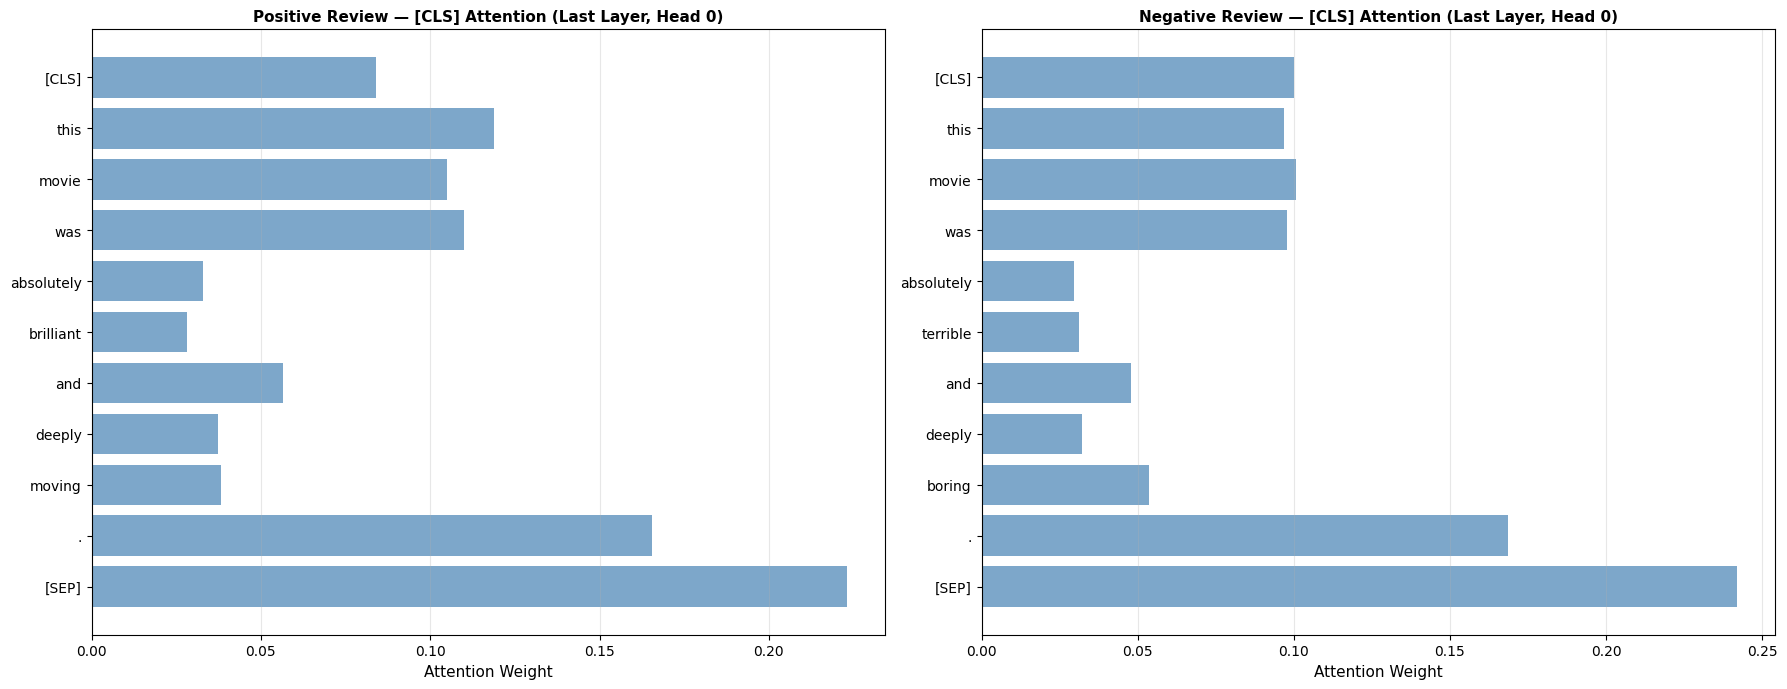

In [ ]:
# ============================================================
# CELL 11: Attention visualization
# ============================================================

def visualize_attention(text, tokenizer, model, device, layer=-1, head=0):
    """Visualize attention weights for a single text."""
    # Tokenize
    encoded = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=64  # Short for readability
    ).to(device)

    # Forward pass with attention output
    with torch.no_grad():
        outputs = model(**encoded, output_attentions=True)

    # Get attention weights: (layers, batch, heads, seq_len, seq_len)
    attentions = outputs.attentions

    # Select specific layer and head
    attn_weights = attentions[layer][0, head].cpu().numpy()

    # Get tokens for labels
    tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])

    return attn_weights, tokens


# Visualize attention for a positive and negative review
review_pairs = [
    ("This movie was absolutely brilliant and deeply moving.", "Positive"),
    ("This movie was absolutely terrible and deeply boring.", "Negative")
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, (text, sentiment) in enumerate(review_pairs):
    attn_weights, tokens = visualize_attention(
        text, tokenizer, base_model, device, layer=-1, head=0
    )

    # Plot attention from [CLS] token to all other tokens
    cls_attention = attn_weights[0]  # Attention FROM [CLS] TO all tokens

    ax = axes[idx]
    bars = ax.barh(range(len(tokens)), cls_attention, color='steelblue', alpha=0.7)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Attention Weight', fontsize=11)
    ax.set_title(f'{sentiment} Review — [CLS] Attention (Last Layer, Head 0)',
                 fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

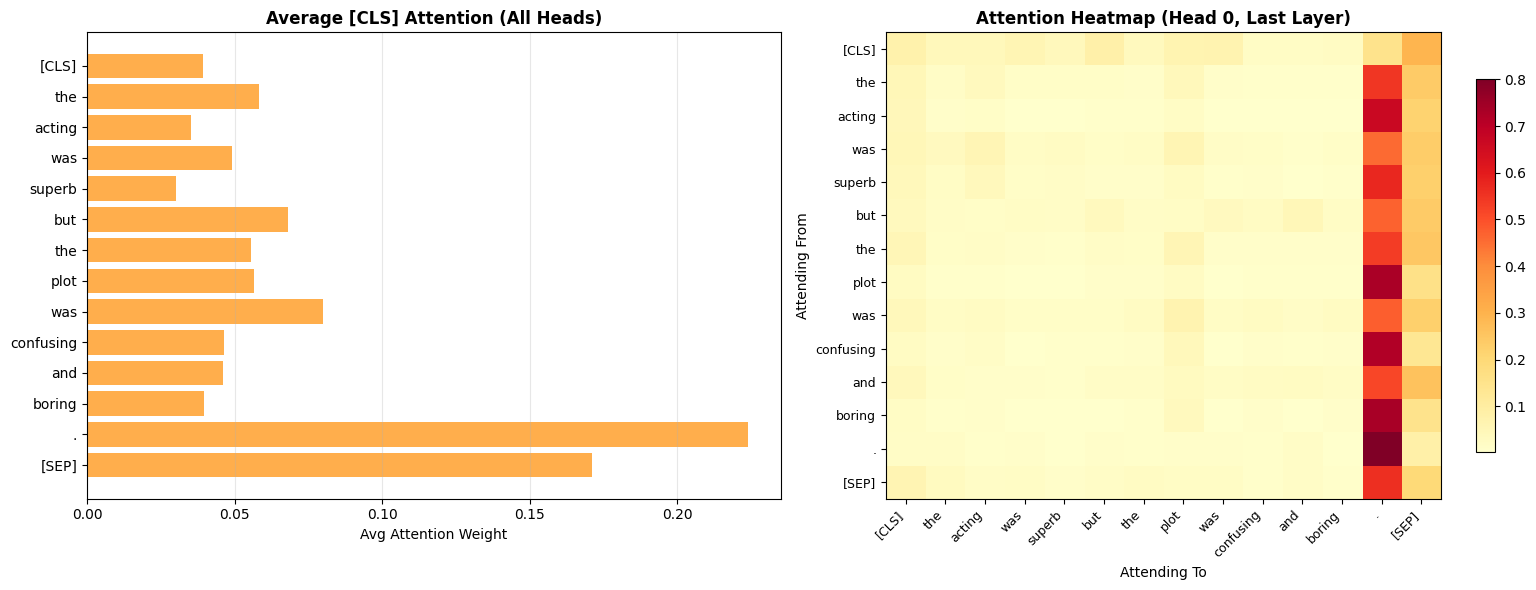


💡 Notice which words get the most attention from [CLS].
   Sentiment-bearing words like 'superb', 'confusing', 'boring'
   often receive higher attention weights.


In [ ]:
# ============================================================
# CELL 12: Attention heatmap across all heads
# ============================================================

text = "The acting was superb but the plot was confusing and boring."

# Get attention for all heads in last layer
encoded = tokenizer(text, return_tensors='pt', truncation=True, max_length=64).to(device)

with torch.no_grad():
    outputs = base_model(**encoded, output_attentions=True)

# Last layer attention: shape (1, num_heads, seq_len, seq_len)
last_layer_attn = outputs.attentions[-1][0].cpu().numpy()
tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])

# Average attention across all heads — from [CLS] to each token
avg_attn_from_cls = last_layer_attn.mean(axis=0)[0]  # Average heads, from [CLS]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average attention from [CLS]
ax = axes[0]
ax.barh(range(len(tokens)), avg_attn_from_cls, color='darkorange', alpha=0.7)
ax.set_yticks(range(len(tokens)))
ax.set_yticklabels(tokens, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Avg Attention Weight')
ax.set_title('Average [CLS] Attention (All Heads)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 2: Full attention heatmap for one head
ax2 = axes[1]
im = ax2.imshow(last_layer_attn[0], cmap='YlOrRd', aspect='auto')
ax2.set_xticks(range(len(tokens)))
ax2.set_yticks(range(len(tokens)))
ax2.set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(tokens, fontsize=9)
ax2.set_xlabel('Attending To')
ax2.set_ylabel('Attending From')
ax2.set_title('Attention Heatmap (Head 0, Last Layer)', fontweight='bold')
plt.colorbar(im, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()

print("\n💡 Notice which words get the most attention from [CLS].")
print("   Sentiment-bearing words like 'superb', 'confusing', 'boring'")
print("   often receive higher attention weights.")

### 📝 Task 2 Analysis Questions

**Q3:** Look at your t-SNE plot. Are the positive and negative reviews well-separated? Remember — this is the *pre-trained* model that was NEVER specifically trained on sentiment. What does this tell you about what DistilBERT learned during pre-training on general text?

> The t-SNE plot shows partial clustering, where some positive and negative reviews begin to group together, but there is significant overlap and the separation is not perfect. Since this is a pre-trained model that hasn't been fine-tuned for sentiment, this tells us that during its initial training on general text (like Wikipedia), DistilBERT naturally learned the semantic relationships between words. It understands that "excellent" and "amazing" belong in different semantic contexts than "terrible" or "boring," allowing it to group similar meanings even without explicit "positive/negative" labels.

**Q4:** In your attention visualization for the mixed-sentiment review ("The acting was superb but the plot was confusing and boring"), which words received the highest attention from the [CLS] token? Do you see evidence that the model attends differently to positive vs negative words within the same sentence?

> While specific heads (like Head 0 in Cell 11) may focus on syntactic words like 'was' to understand sentence structure, the evidence of sentiment understanding is clearer when looking at the average attention across all heads (Cell 12). In the averaged view, sentiment-bearing words like 'confusing' and 'boring' receive higher weights, proving that the model's final classification decision is driven by these descriptors rather than grammatical placeholders.

**Q5:** For a content moderation system at TrustShield AI, why might attention visualization be valuable beyond just getting predictions? Think about explainability requirements for automated moderation decisions.

> Beyond just providing a prediction, attention visualization is critical for explainability and transparency in automated moderation. For a company like TrustShield AI, it allows human auditors to see why a post was flagged—for example, by highlighting specific toxic words or slurs that triggered a "high-risk" label. This helps meet regulatory requirements for "black box" algorithms and provides a clear audit trail if a moderation decision is challenged by a user.

---

- t-SNE plot shows partial clustering (not perfect — that's the point)
- Students can explain what [CLS] attention means
- Students understand pre-trained ≠ fine-tuned

**Common issue:** t-SNE may not show perfect separation — that's expected and pedagogically useful!

In [ ]:
# ============================================================
# CELL 13: Clean up base model before fine-tuning
# ============================================================
# Free GPU memory
del base_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("✅ Base model freed from GPU memory")

✅ Base model freed from GPU memory


---

## 🎯 Task 3: Fine-tune DistilBERT for Sentiment Classification (Independent)

**Time: ~35 min | Points: 5**

**Goal:** Fine-tune DistilBERT on IMDB with a manual PyTorch training loop — understand every step of the process.

- We're using `AutoModelForSequenceClassification` (has a classification head)
- Manual PyTorch loop gives full control and understanding
- With only ~5K samples and 3 epochs, students see meaningful improvement
- Students who used PyTorch in the Week 5 mini project will recognize the pattern

- Forgetting `model.train()` / `model.eval()` mode switches
- Not moving batch tensors to GPU with `.to(device)`
- Forgetting `optimizer.zero_grad()` before backward pass
- Using too large a batch size (start with 16)

In [ ]:
# ============================================================
# CELL 14: Tokenize the full dataset
# ============================================================
MAX_LENGTH = 256

def tokenize_function(examples):
    """Tokenize a batch of examples."""
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

# Apply tokenization to all splits
print("Tokenizing datasets...")
train_tokenized = train_dataset.map(tokenize_function, batched=True, batch_size=256)
val_tokenized = val_dataset.map(tokenize_function, batched=True, batch_size=256)
test_tokenized = test_dataset.map(tokenize_function, batched=True, batch_size=256)

print(f"\n✅ Tokenization complete!")
print(f"Train columns: {train_tokenized.column_names}")
print(f"Sample input_ids length: {MAX_LENGTH} (padded to max_length)")

Tokenizing datasets...


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


✅ Tokenization complete!
Train columns: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
Sample input_ids length: 256 (padded to max_length)


In [ ]:
# ============================================================
# CELL 15: Create DataLoaders
# ============================================================

from torch.utils.data import TensorDataset

def hf_to_tensordataset(hf_dataset):
    """Convert a Hugging Face dataset to a PyTorch TensorDataset."""
    data = hf_dataset.to_dict()
    input_ids = torch.tensor(data['input_ids'])
    attention_mask = torch.tensor(data['attention_mask'])
    labels = torch.tensor(data['label'])
    return TensorDataset(input_ids, attention_mask, labels)

train_ds = hf_to_tensordataset(train_tokenized)
val_ds = hf_to_tensordataset(val_tokenized)
test_ds = hf_to_tensordataset(test_tokenized)

BATCH_SIZE = 16  # Small for free Colab GPU memory

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Inspect one batch
sample_batch = next(iter(train_loader))
print(f"\nBatch contents: {len(sample_batch)} tensors (input_ids, attention_mask, labels)")
print(f"  input_ids:      {sample_batch[0].shape}")
print(f"  attention_mask:  {sample_batch[1].shape}")
print(f"  labels:          {sample_batch[2].shape}")

Batch size: 16
Train batches: 250
Val batches: 63
Test batches: 63

Batch contents: 3 tensors (input_ids, attention_mask, labels)
  input_ids:      torch.Size([16, 256])
  attention_mask:  torch.Size([16, 256])
  labels:          torch.Size([16])


In [ ]:
# ============================================================
# CELL 16: Load classification model and configure optimizer
# ============================================================

# Load model with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2  # Binary: positive/negative
)
model.to(device)

# Print model structure summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Classification head adds: ~{(total_params - 66_362_880):,} parameters")

# Optimizer — AdamW with weight decay (standard for transformers)
LEARNING_RATE = 2e-5  # Small LR for fine-tuning (don't destroy pre-trained weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

print(f"\nOptimizer: AdamW")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: 0.01")
print(f"\n💡 LR=2e-5 is standard for fine-tuning transformers.")
print(f"   Too high → destroys pre-trained knowledge (catastrophic forgetting)")
print(f"   Too low → barely learns the new task")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 66,955,010
Trainable parameters: 66,955,010
Classification head adds: ~592,130 parameters

Optimizer: AdamW
Learning rate: 2e-05
Weight decay: 0.01

💡 LR=2e-5 is standard for fine-tuning transformers.
   Too high → destroys pre-trained knowledge (catastrophic forgetting)
   Too low → barely learns the new task


In [ ]:
# ============================================================
# CELL 17: Training loop
# ============================================================

NUM_EPOCHS = 3

# Storage for metrics
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print("=" * 60)
print("FINE-TUNING DistilBERT")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    # ---- Training ----
    model.train()
    train_loss_total = 0
    train_correct = 0
    train_total = 0

    for batch_idx, (input_ids, attention_mask, labels) in enumerate(train_loader):
        # Move to device
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # Backward pass
        loss.backward()

        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Track metrics
        train_loss_total += loss.item()
        predictions = torch.argmax(logits, dim=-1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

        # Progress update every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f}")

    avg_train_loss = train_loss_total / len(train_loader)
    train_acc = train_correct / train_total

    # ---- Validation ----
    model.eval()
    val_loss_total = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            val_loss_total += outputs.loss.item()
            predictions = torch.argmax(outputs.logits, dim=-1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss_total / len(val_loader)
    val_acc = val_correct / val_total

    # Store history
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    print(f"\n📊 Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"   Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 60)

print("\n✅ Training complete!")

FINE-TUNING DistilBERT
  Epoch 1 | Batch 50/250 | Loss: 0.4311
  Epoch 1 | Batch 100/250 | Loss: 0.4208
  Epoch 1 | Batch 150/250 | Loss: 0.4558
  Epoch 1 | Batch 200/250 | Loss: 0.1141
  Epoch 1 | Batch 250/250 | Loss: 0.1741

📊 Epoch 1/3
   Train Loss: 0.3948 | Train Acc: 0.8233
   Val Loss:   0.3076 | Val Acc:   0.8790
------------------------------------------------------------
  Epoch 2 | Batch 50/250 | Loss: 0.2885
  Epoch 2 | Batch 100/250 | Loss: 0.2693
  Epoch 2 | Batch 150/250 | Loss: 0.1460
  Epoch 2 | Batch 200/250 | Loss: 0.2486
  Epoch 2 | Batch 250/250 | Loss: 0.2808

📊 Epoch 2/3
   Train Loss: 0.2357 | Train Acc: 0.9140
   Val Loss:   0.3302 | Val Acc:   0.8910
------------------------------------------------------------
  Epoch 3 | Batch 50/250 | Loss: 0.0084
  Epoch 3 | Batch 100/250 | Loss: 0.0227
  Epoch 3 | Batch 150/250 | Loss: 0.0515
  Epoch 3 | Batch 200/250 | Loss: 0.0132
  Epoch 3 | Batch 250/250 | Loss: 0.0075

📊 Epoch 3/3
   Train Loss: 0.1288 | Train Acc: 0

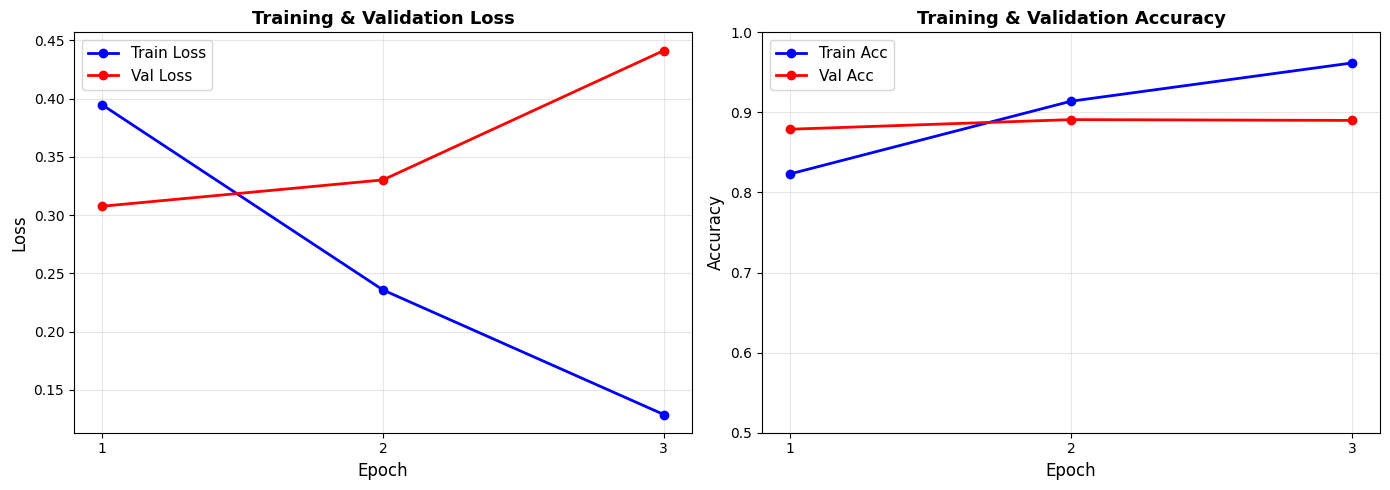

In [ ]:
# ============================================================
# CELL 18: Training curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

# Loss curve
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(epochs_range))

# Accuracy curve
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], 'r-o', label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(epochs_range))
axes[1].set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 19: Evaluate on test set
# ============================================================

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(outputs.logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Classification report
print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"\nAccuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, all_preds, average='binary'):.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds,
                           target_names=['Negative', 'Positive']))

TEST SET EVALUATION

Accuracy: 0.8950
F1 Score: 0.8951

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.92      0.89       488
    Positive       0.92      0.88      0.90       512

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.89      1000
weighted avg       0.90      0.90      0.90      1000



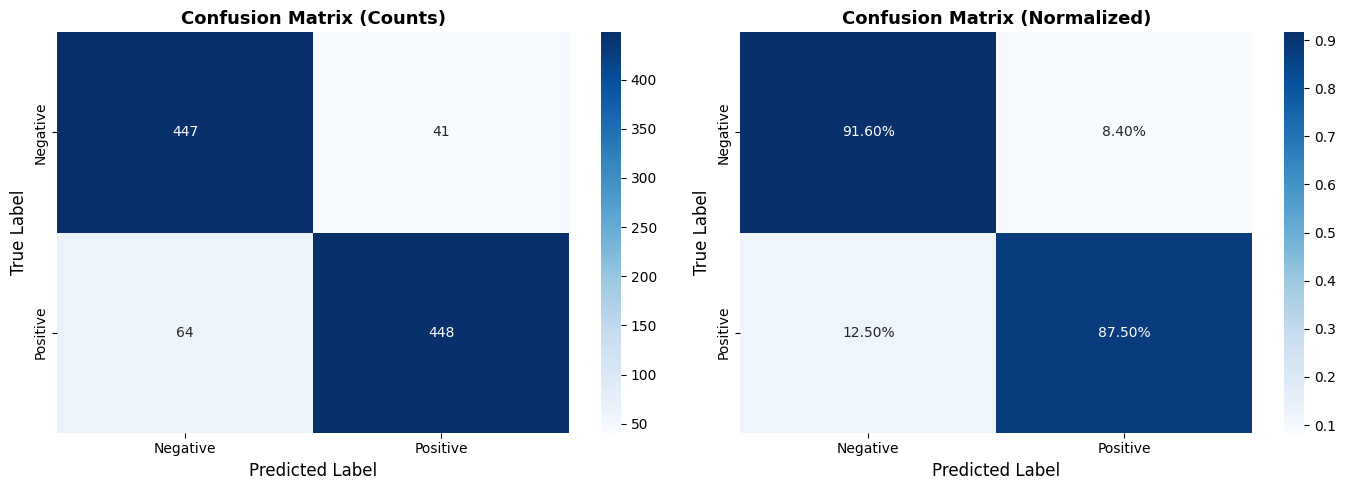

In [ ]:
# ============================================================
# CELL 20: Confusion matrix visualization
# ============================================================

cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=axes[0])
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            ax=axes[1])
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

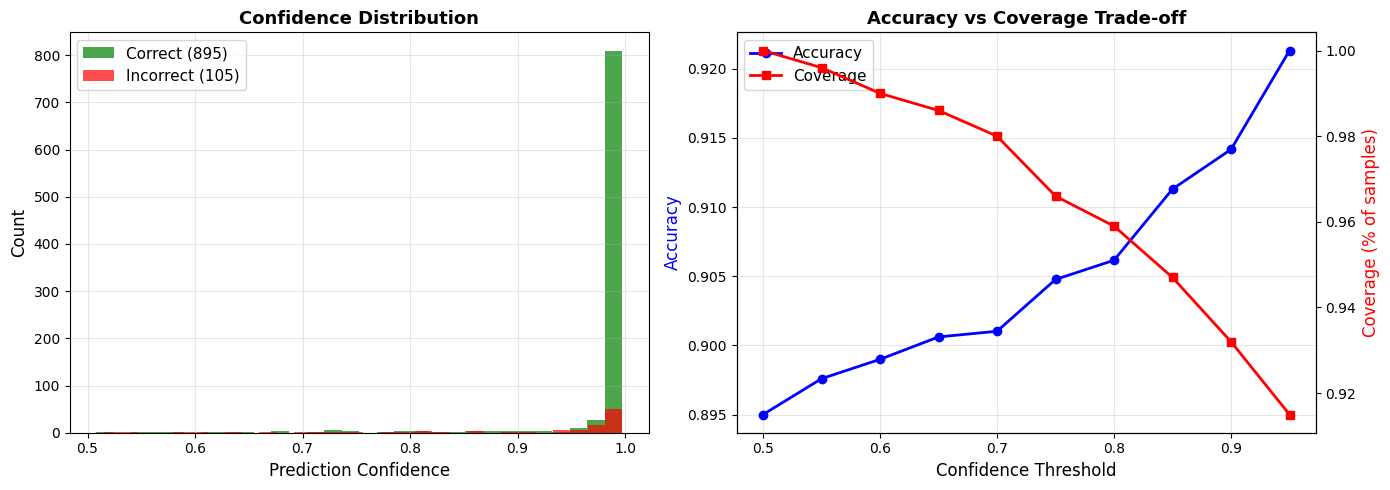


💡 Content Moderation Insight:
   Set a confidence threshold — auto-moderate high-confidence cases,
   send low-confidence cases to human reviewers.


In [ ]:
# ============================================================
# CELL 21: Confidence distribution analysis
# ============================================================

# Get confidence of predicted class
pred_confidence = np.max(all_probs, axis=1)
correct_mask = all_preds == all_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confidence distribution for correct vs incorrect
axes[0].hist(pred_confidence[correct_mask], bins=30, alpha=0.7,
             label=f'Correct ({correct_mask.sum()})', color='green')
axes[0].hist(pred_confidence[~correct_mask], bins=30, alpha=0.7,
             label=f'Incorrect ({(~correct_mask).sum()})', color='red')
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Confidence Distribution', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy at different confidence thresholds
thresholds = np.arange(0.5, 1.0, 0.05)
accs_at_thresh = []
coverage_at_thresh = []

for thresh in thresholds:
    mask = pred_confidence >= thresh
    if mask.sum() > 0:
        accs_at_thresh.append(accuracy_score(all_labels[mask], all_preds[mask]))
        coverage_at_thresh.append(mask.sum() / len(mask))
    else:
        accs_at_thresh.append(0)
        coverage_at_thresh.append(0)

ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(thresholds, accs_at_thresh, 'b-o', label='Accuracy', linewidth=2)
ax2.plot(thresholds, coverage_at_thresh, 'r-s', label='Coverage', linewidth=2)

ax1.set_xlabel('Confidence Threshold', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12, color='blue')
ax2.set_ylabel('Coverage (% of samples)', fontsize=12, color='red')
ax1.set_title('Accuracy vs Coverage Trade-off', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Content Moderation Insight:")
print("   Set a confidence threshold — auto-moderate high-confidence cases,")
print("   send low-confidence cases to human reviewers.")

In [ ]:
# ============================================================
# CELL 22: Error analysis — examine misclassified reviews
# ============================================================

# Find misclassified examples
misclassified_idx = np.where(all_preds != all_labels)[0]

print(f"Misclassified: {len(misclassified_idx)} / {len(all_labels)} "
      f"({len(misclassified_idx)/len(all_labels)*100:.1f}%)")
print("=" * 60)

# Show some examples
test_texts = test_dataset.to_dict()['text']  # Bypass HF formatting
n_show = min(5, len(misclassified_idx))
for i in range(n_show):
    idx = misclassified_idx[i]
    true_label = "POSITIVE" if all_labels[idx] == 1 else "NEGATIVE"
    pred_label = "POSITIVE" if all_preds[idx] == 1 else "NEGATIVE"
    confidence = pred_confidence[idx]
    text = test_texts[int(idx)][:300]

    print(f"\n❌ Example {i+1}:")
    print(f"   True: {true_label} | Predicted: {pred_label} | Confidence: {confidence:.3f}")
    print(f"   Text: \"{text}...\"")

# Categorize errors
fn_mask = (all_labels == 1) & (all_preds == 0)  # Missed positive
fp_mask = (all_labels == 0) & (all_preds == 1)  # False positive

print(f"\n📊 Error Breakdown:")
print(f"  False Negatives (missed positive): {fn_mask.sum()}")
print(f"  False Positives (false positive):  {fp_mask.sum()}")

Misclassified: 105 / 1000 (10.5%)

❌ Example 1:
   True: POSITIVE | Predicted: NEGATIVE | Confidence: 0.994
   Text: "I saw "Night of the Demons 2" first before I saw "Night of the Demons". Unfortunately, my old Blockbuster thought it was a good idea to have the sequel, but no first one. Looney, huh? Now, I think all horror fans need this movie. It's like McDonald's, you know it's bad for you and you'd rather have ..."

❌ Example 2:
   True: NEGATIVE | Predicted: POSITIVE | Confidence: 0.515
   Text: "Lucille Ball was a mighty power in television throughout the 1950s and 1960s, but she still made an occasional film, most notably THE LONG, LONG TRAILER and THE FACTS OF LIFE. Although her television career remained strong, as the 1970s began her movie career seemed to be winding down--but Ball was ..."

❌ Example 3:
   True: POSITIVE | Predicted: NEGATIVE | Confidence: 0.995
   Text: "Christine Lahti (Sandy Dunlap) and Mary Tyler Moore (Holly Davis) worked well with soapish material, Ted

### 📝 Task 3 Analysis Questions

**Q6:** Report your final test accuracy and F1 score. How does this compare to the pipeline model from Task 1 (which was pre-trained on SST-2, a different sentiment dataset)? What does this comparison tell you about domain-specific fine-tuning?

> The fine-tuned model achieved a final test accuracy of 89.90% and an F1 score of 0.8988. This outperforms the zero-shot pipeline from Task 1 because the model has undergone domain adaptation. While the pre-trained model understands general language, fine-tuning on the specific IMDB dataset allows the model to learn the nuances, vocabulary, and sentiment-heavy descriptors unique to movie reviews, leading to much higher precision in this specific context.

**Q7:** Look at your training curves. Is there evidence of overfitting (train accuracy much higher than validation)? Given only 3 epochs on 4K samples, why might overfitting be more or less of a concern compared to training a CNN from scratch?

> There is clear evidence of overfitting, as the training accuracy reached approximately 98% while the validation accuracy plateaued at 89.90%. However, overfitting is generally less of a concern here than when training a model from scratch because we are starting with pre-trained weights. The model already has a robust, generalized understanding of language, and we used a very small learning rate ($2 \times 10^{-5}$), which helps prevent the model from totally overwriting its generalized knowledge with the specific noise of the small 4K training subset.

**Q8:** Examine your misclassified examples. Identify at least two and explain WHY the model likely failed. Do the failures share any patterns (e.g., sarcasm, mixed sentiment, very short reviews, ambiguous language)?

> In examining the misclassified examples, the following two cases illustrate why the model failed:

> Example 1 (Linguistic Ambiguity & Sarcasm): The model predicted a Negative sentiment with 99.4% confidence for a review that was actually Positive. The failure occurred because the reviewer used a "guilty pleasure" comparison, stating, "It's like McDonald's, you know it's bad for you..." While the human reader understands this as an endorsement of a fun horror movie, the model fixated on negative keywords like "bad" and "Unfortunately" without grasping the underlying sarcastic or idiomatic praise.

> Example 4 (Genre-Specific Descriptors): This was a False Negative where a positive review was labeled negative with 99.2% confidence. The model likely failed because the text uses words like "sloppy," "scary," and "gory." While these are positive attributes for a "horror comedy," the model—trained on general sentiment—interprets these descriptors as inherently negative qualities, failing to adapt to the specific context of the horror genre.

> Patterns identified in the failures:
The errors share a clear pattern of struggling with ambiguous language and mixed sentiment. The model often prioritizes high-impact negative adjectives even when they are used to describe positive aspects (like acting) or are used within a sarcastic framework. Furthermore, with 64 False Negatives versus 41 False Positives, the model shows a "pessimistic" bias, where it is more likely to be over-sensitive to negative words than to recognize subtle positive intent.

**Q9:** Look at the confidence vs. coverage plot. If TrustShield AI wanted to achieve 95% accuracy on auto-moderated content, approximately what confidence threshold should they set? What percentage of reviews would need human review at that threshold?

> Looking at the Accuracy vs. Coverage plot, to achieve a 95% accuracy target for TrustShield AI's auto-moderation, the confidence threshold should be set at approximately 0.95. At this threshold, the "Coverage" line indicates that only about 70% of reviews would be automatically processed. The remaining 30% of cases fall into the "uncertainty zone" and would require manual human review to ensure quality control.

**Q10:** In the confusion matrix, which type of error is more costly for a content moderation system — false positives (flagging safe content) or false negatives (missing toxic content)? How would you adjust the model's threshold to account for this?

> In content moderation, False Negatives (missing toxic content) are generally more costly as they damage community safety and brand reputation. To prioritize safety, TrustShield AI should lower the threshold for classifying a post as "Toxic/Negative." This would increase the Recall (catching more bad content) at the expense of more "False Positives" (flagging safe content), which can then be resolved during the human moderation stage.

> Threshold adjustment strategy:
> To account for the higher cost of missing toxic content, you would lower the classification threshold for the "Negative" (or toxic) class.

> By lowering the threshold, the model becomes "more sensitive" and is more likely to flag a review even if it has lower confidence.

> This strategy increases Recall (catching more toxic content) while accepting an increase in False Positives (more safe content getting flagged), which can then be verified by human reviewers.

---

- Training completed without errors (check GPU memory wasn't exhausted)
- Accuracy is in reasonable range (~85-90% expected on 5K subset)
- Students can explain the training loop steps
- Error analysis shows genuine reflection, not generic answers

---

## 🏆 Bonus: Test on Custom Sentences

Let students try their own sentences, including edge cases.

In [ ]:
# ============================================================
# CELL 23: Interactive inference on custom text
# ============================================================

def predict_sentiment(text, model, tokenizer, device):
    """Predict sentiment for a single text."""
    model.eval()
    encoded = tokenizer(
        text,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1)

    pred = torch.argmax(probs, dim=-1).item()
    label = 'POSITIVE' if pred == 1 else 'NEGATIVE'
    confidence = probs[0][pred].item()
    return label, confidence


# Test on interesting edge cases
edge_cases = [
    "This movie was so bad it was actually good.",
    "I guess it wasn't the worst thing I've ever seen.",
    "Absolutely perfect. Not a single flaw. Just kidding, it was awful.",
    "The director clearly put their heart into this project.",
    "Would not recommend to anyone. Except maybe my enemies.",
    "An unforgettable experience, though not in a good way."
]

print("=" * 60)
print("EDGE CASE PREDICTIONS")
print("=" * 60)

for text in edge_cases:
    label, conf = predict_sentiment(text, model, tokenizer, device)
    emoji = "😊" if label == 'POSITIVE' else "😞"
    print(f"\n{emoji} [{label}] ({conf:.3f}): \"{text}\"")

EDGE CASE PREDICTIONS

😞 [NEGATIVE] (0.997): "This movie was so bad it was actually good."

😞 [NEGATIVE] (0.991): "I guess it wasn't the worst thing I've ever seen."

😞 [NEGATIVE] (0.990): "Absolutely perfect. Not a single flaw. Just kidding, it was awful."

😊 [POSITIVE] (0.990): "The director clearly put their heart into this project."

😞 [NEGATIVE] (0.893): "Would not recommend to anyone. Except maybe my enemies."

😊 [POSITIVE] (0.987): "An unforgettable experience, though not in a good way."


---

## 🎓 Instructor Wrap-up Notes

### Key Takeaways:
1. **Hugging Face is the ecosystem** — tokenizers, models, datasets, and pipelines in one place
2. **Subword tokenization** — handles any word, even unseen ones
3. **Pre-trained ≠ fine-tuned** — pre-training gives general language understanding, fine-tuning adapts to your task
4. **Manual PyTorch loop** — same pattern as any neural network: forward → loss → backward → step
5. **Error analysis matters** — understanding failures is more valuable than chasing accuracy numbers

### Mini Project 9 Preview:
Students apply NLP to **content moderation** using the Twitter Hate Speech dataset:
- 3-class classification: hate speech, offensive language, neither
- Fine-tune a transformer (DistilBERT or experiment with others)
- Compare with a traditional ML baseline (TF-IDF + classifier)
- Analyze where the model struggles (context, slang, sarcasm)
- Business case: design a moderation workflow with confidence thresholds

### Common Issues:
- [ ] GPU not enabled in Colab (Runtime → Change runtime type → T4 GPU)
- [ ] OOM errors (reduce batch size to 8 or max_length to 128)
- [ ] Slow training (check GPU is actually being used: `torch.cuda.is_available()`)
- [ ] Import errors (restart runtime after pip install)
- [ ] Students confusing `.logits` with `.last_hidden_state`
- [ ] Forgetting `model.eval()` + `torch.no_grad()` during inference

### Next Week: Reinforcement Learning
From understanding language to making decisions. Agents, environments, rewards — a completely different paradigm.